notebook for testing functions as they migrate from notebook to src/

In [1]:
# imports
from src.data.loader import (
	load_dataset, 
	load_raw
)
from src.visualization.data_visualization import (
	plot_label_distribution,
	plot_correlation_heatmap,
	plot_correlated_pairs
)

from src.data.resampler import resample

from src.models.lgbm import (
    train_lightgbm_classifier,
    classification_report_for_model
)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

In [2]:
# load data
df = load_dataset()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading cleaned dataset from cache at cache/cleaned.parquet
Shape: (2522362, 62)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 

In [3]:
# verify cleaning was applied
assert df.isnull().sum().sum() == 0, "Data contains missing values"
assert 'Label' in df.columns, "Label column is missing"
assert df.shape[1] == 62, f"Expected 62 columns after cleaning, got {df.shape[1]}"
print("Data loading and verification successful.")

Data loading and verification successful.


Loading raw dataset from Kaggle...
Raw shape: 2,830,743 rows, 79 columns


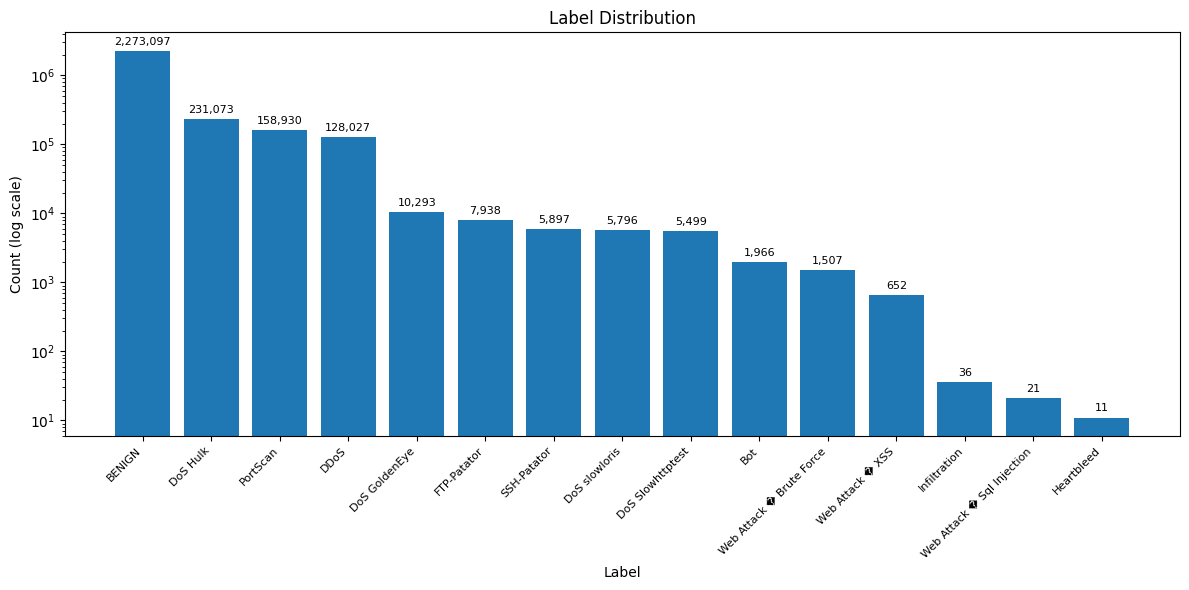

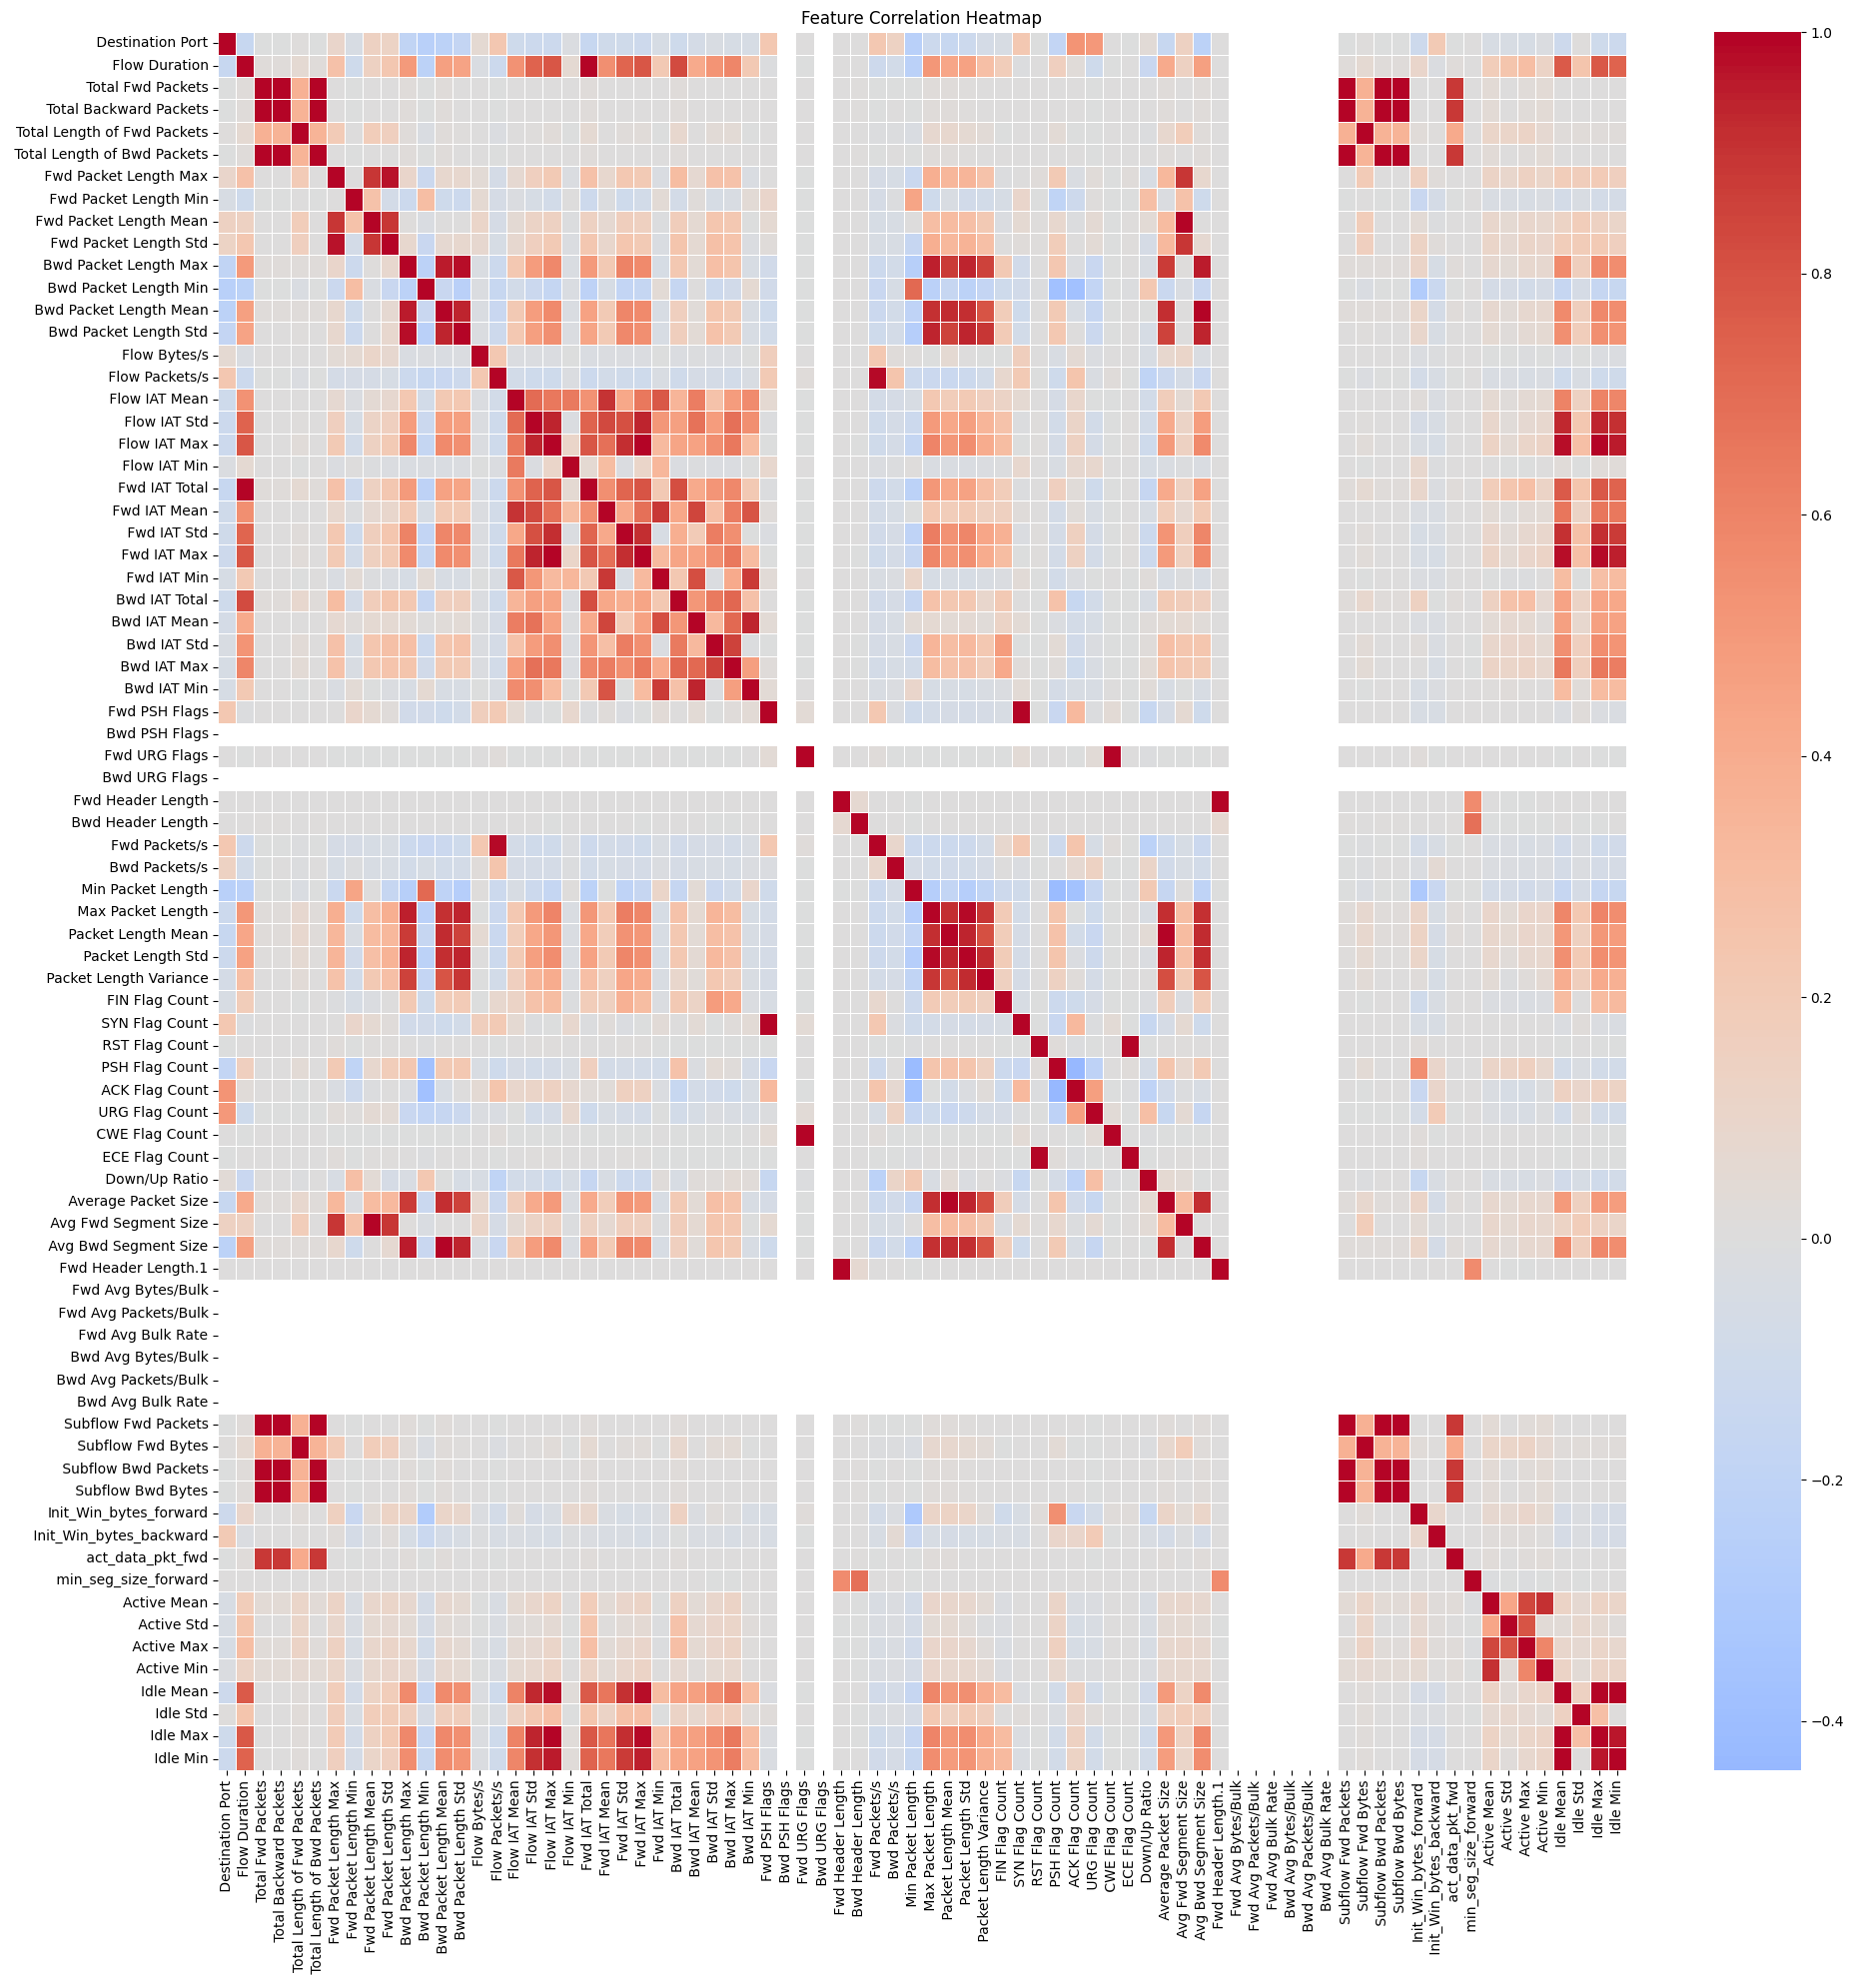

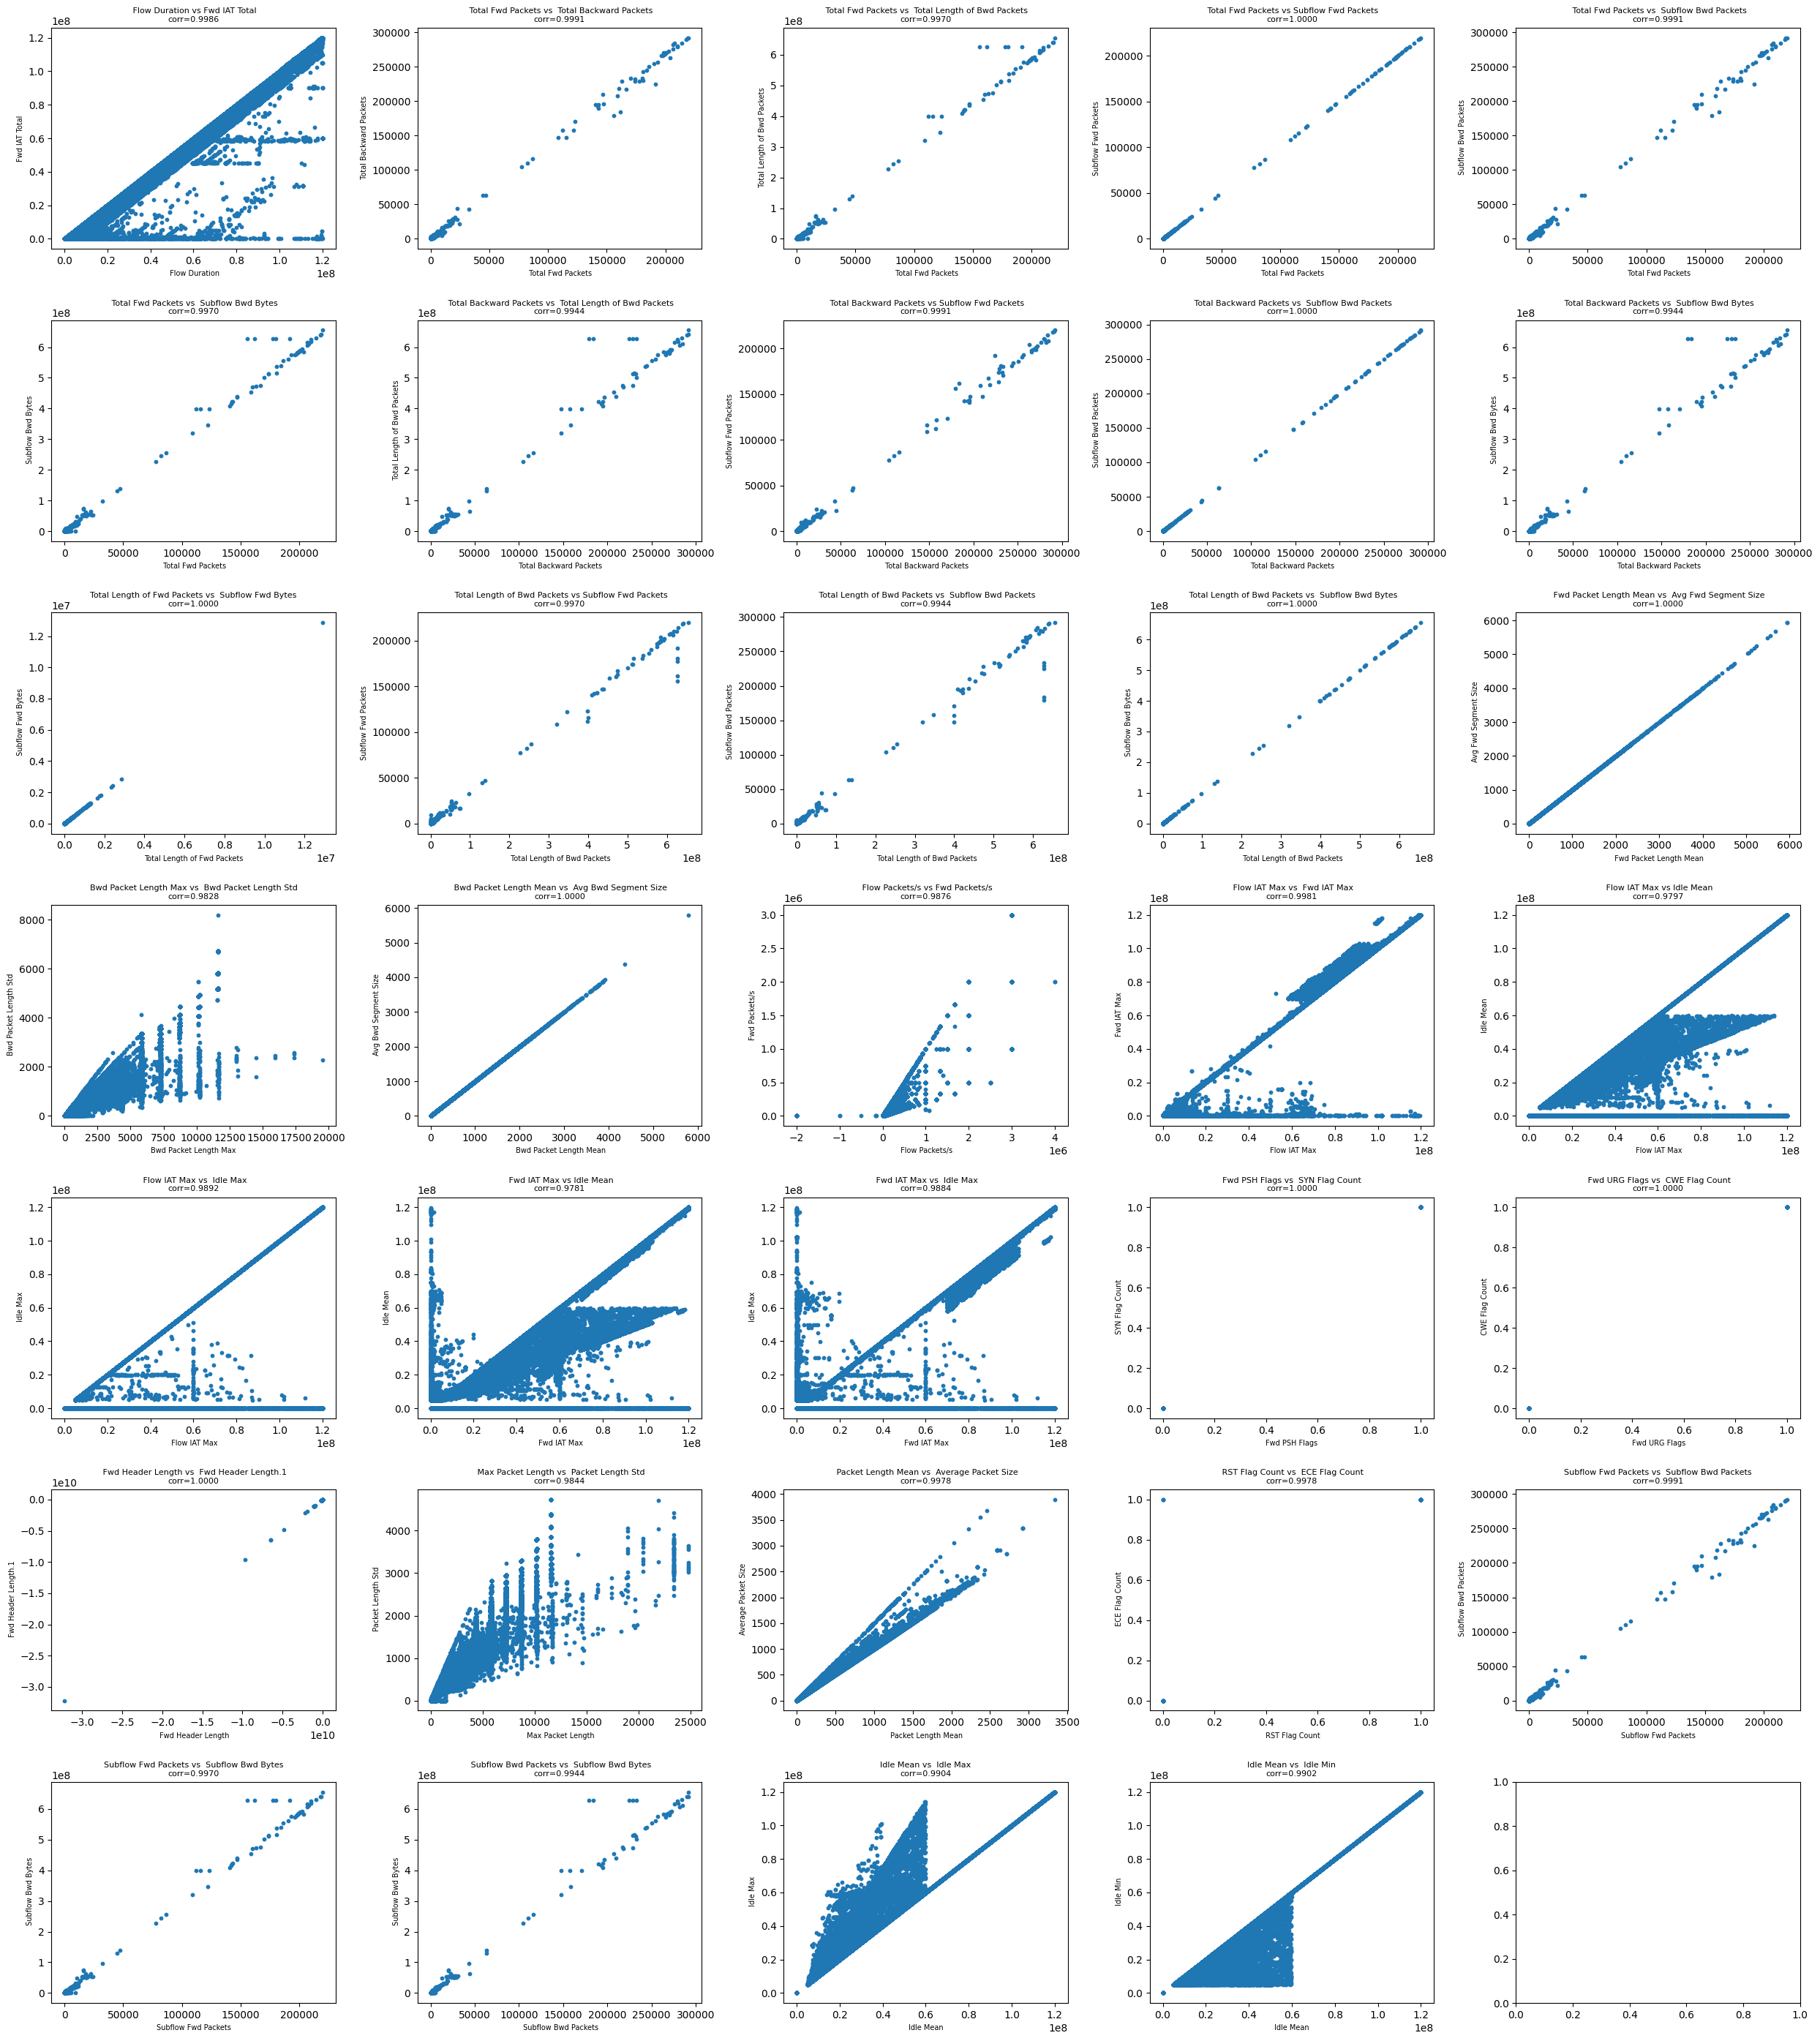

In [4]:
# test visualization
raw_df = load_raw()
plot_label_distribution(raw_df)
plot_correlation_heatmap(raw_df)
plot_correlated_pairs(raw_df, threshold=0.97)

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_resampled, y_resampled = resample(X_train, y_train)
print(f"Original class distribution: {y_train.value_counts().to_dict()}")
print(f"Resampled class distribution: {y_resampled.value_counts().to_dict()}")

Resampled class distribution:
Label
BENIGN                        138007
Bot                           138007
DDoS                          138007
DoS GoldenEye                 138007
DoS Hulk                      138007
DoS Slowhttptest              138007
DoS slowloris                 138007
FTP-Patator                   138007
Heartbleed                    138007
Infiltration                  138007
PortScan                      138007
SSH-Patator                   138007
Web Attack - Brute Force      138007
Web Attack - Sql Injection    138007
Web Attack - XSS              138007
Original class distribution: {'BENIGN': 1677323, 'DoS Hulk': 138007, 'DDoS': 102429, 'PortScan': 72731, 'DoS GoldenEye': 8212, 'FTP-Patator': 4748, 'DoS slowloris': 4335, 'DoS Slowhttptest': 4200, 'SSH-Patator': 2591, 'Bot': 1558, 'Web Attack - Brute Force': 1161, 'Web Attack - XSS': 541, 'Infiltration': 25, 'Web Attack - Sql Injection': 18, 'Heartbleed': 10}
Resampled class distribution: {'BENIGN': 138007

# Logistic Regression

In [7]:
from src.models.logistic import (
    train_logistic_classifier,
    predict_labels,
    classification_report_for_model,
)

In [8]:
artifacts = train_logistic_classifier(
    X_train,
    y_train,
    random_state=42,
    max_iter=1000,
)

/home/levi/School/cs3540/cs3540-final/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
print("Classification Report:")
print(classification_report_for_model(artifacts, X_test, y_test))

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN      1.000     0.819     0.901    419161
                       Bot      0.013     0.985     0.025       395
                      DDoS      0.943     0.996     0.968     25587
             DoS GoldenEye      0.501     0.982     0.664      2074
                  DoS Hulk      0.830     0.998     0.906     34842
          DoS Slowhttptest      0.369     0.984     0.537      1028
             DoS slowloris      0.337     0.977     0.501      1050
               FTP-Patator      0.485     0.995     0.652      1185
                Heartbleed      0.500     1.000     0.667         1
              Infiltration      0.002     0.727     0.005        11
                  PortScan      0.699     0.998     0.822     18088
               SSH-Patator      0.532     0.917     0.673       628
  Web Attack - Brute Force      0.037     0.482     0.069       309
Web Attack - Sql Injecti

# Random Forest

In [10]:
from src.models.rf import (
    train_rf_classifier,
    predict_labels,
    classification_report_for_model,
)

In [18]:
artifacts = train_rf_classifier(
    X_train,
    y_train,
    n_estimators=200,
    max_depth=100,
    random_state=42,
)

In [19]:
print("\nClassification Report:")
print(classification_report_for_model(artifacts, X_test, y_test))


Classification Report:
                            precision    recall  f1-score   support

                    BENIGN      0.999     0.999     0.999    419161
                       Bot      0.883     0.724     0.796       395
                      DDoS      1.000     1.000     1.000     25587
             DoS GoldenEye      0.998     0.995     0.997      2074
                  DoS Hulk      0.998     0.997     0.997     34842
          DoS Slowhttptest      0.988     0.990     0.989      1028
             DoS slowloris      0.995     0.993     0.994      1050
               FTP-Patator      1.000     0.997     0.998      1185
                Heartbleed      1.000     1.000     1.000         1
              Infiltration      1.000     0.636     0.778        11
                  PortScan      0.989     0.989     0.989     18088
               SSH-Patator      1.000     0.992     0.996       628
  Web Attack - Brute Force      0.753     0.799     0.776       309
Web Attack - Sql Inject

# LightGBM

In [6]:
artifacts = train_lightgbm_classifier(
    X_train,
    y_train,
    X_valid=X_test,
    y_valid=y_test,
    class_weight="balanced",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
)

print(classification_report_for_model(
    artifacts,
    X_test,
    y_test
))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12532
[LightGBM] [Info] Number of data points in the train set: 2017889, number of used features: 60
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805